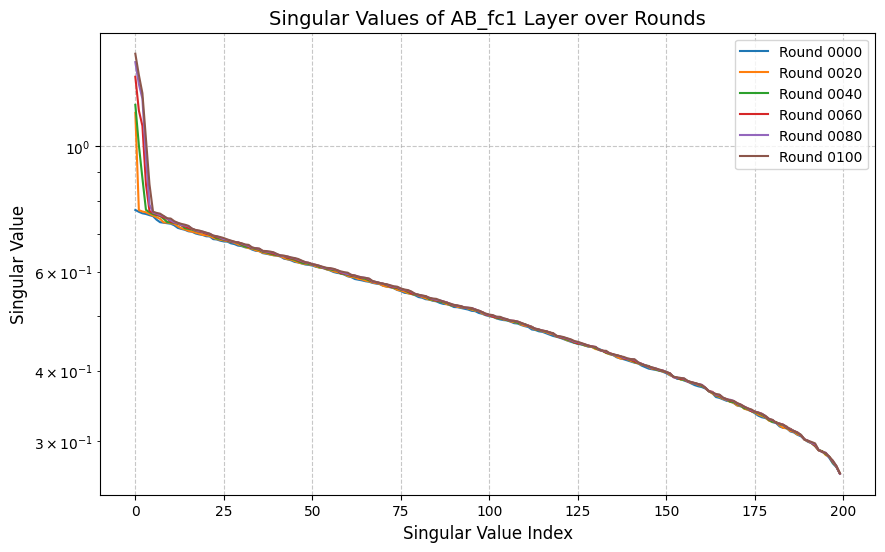

In [1]:
import json
import os
import matplotlib.pyplot as plt

# 1. 定义要读取的文件轮次列表
steps = ['0000', '0020', '0040', '0060', '0080', '0100']

# 2. 创建画布
plt.figure(figsize=(10, 6))
#plt.xscale('log')
plt.yscale('log')


# 3. 遍历读取文件并绘图
for step in steps:
    filename = f"round_{step}.json"
    
    # 检查文件是否存在，避免因找不到文件而报错
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 提取 _fc1 层的奇异值（注意键名带有下划线）
        if "AB_singular_values" in data and "_fc1" in data["AB_singular_values"]:
            singular_values = data["AB_singular_values"]["_fc1"]
            
            # 绘制当前文件的曲线
            plt.plot(singular_values, label=f'Round {step}', linewidth=1.5)
        else:
            print(f"警告: 文件 {filename} 中未找到对应的 _fc1 数据。")
    else:
        print(f"找不到文件: {filename}")

# 4. 设置图表的标题、坐标轴标签等属性
plt.title("Singular Values of AB_fc1 Layer over Rounds", fontsize=14)
plt.xlabel("Singular Value Index", fontsize=12)
plt.ylabel("Singular Value", fontsize=12)

# 【可选】：由于奇异值通常衰减极快（长尾效应），使用对数坐标往往能看清更多细节。
# 如果您发现图像上的线都挤在底部，可以取消下面这行代码的注释来开启 Y 轴的对数坐标：
# plt.yscale('log')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. 保存或显示图像
# plt.savefig("fc1_singular_values_all.png", dpi=300, bbox_inches='tight') # 取消注释可将图片保存到本地
plt.show()

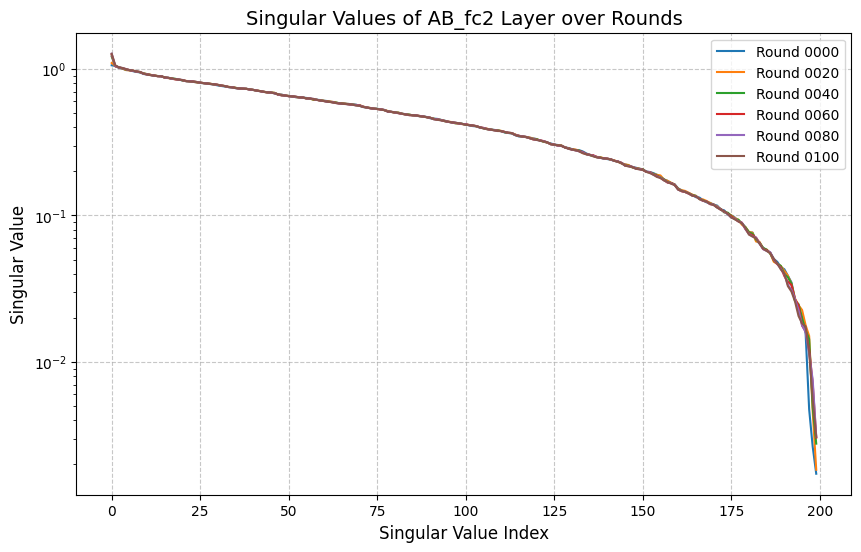

In [2]:
import json
import os
import matplotlib.pyplot as plt

# 1. 定义要读取的文件轮次列表
steps = ['0000', '0020', '0040', '0060', '0080', '0100']

# 2. 创建画布
plt.figure(figsize=(10, 6))
#plt.xscale('log')
plt.yscale('log')


# 3. 遍历读取文件并绘图
for step in steps:
    filename = f"round_{step}.json"
    
    # 检查文件是否存在，避免因找不到文件而报错
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 提取 _fc1 层的奇异值（注意键名带有下划线）
        if "AB_singular_values" in data and "_fc2" in data["AB_singular_values"]:
            singular_values = data["AB_singular_values"]["_fc2"]
            
            # 绘制当前文件的曲线
            plt.plot(singular_values, label=f'Round {step}', linewidth=1.5)
        else:
            print(f"警告: 文件 {filename} 中未找到对应的 _fc2 数据。")
    else:
        print(f"找不到文件: {filename}")

# 4. 设置图表的标题、坐标轴标签等属性
plt.title("Singular Values of AB_fc2 Layer over Rounds", fontsize=14)
plt.xlabel("Singular Value Index", fontsize=12)
plt.ylabel("Singular Value", fontsize=12)

# 【可选】：由于奇异值通常衰减极快（长尾效应），使用对数坐标往往能看清更多细节。
# 如果您发现图像上的线都挤在底部，可以取消下面这行代码的注释来开启 Y 轴的对数坐标：
# plt.yscale('log')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. 保存或显示图像
# plt.savefig("fc1_singular_values_all.png", dpi=300, bbox_inches='tight') # 取消注释可将图片保存到本地
plt.show()

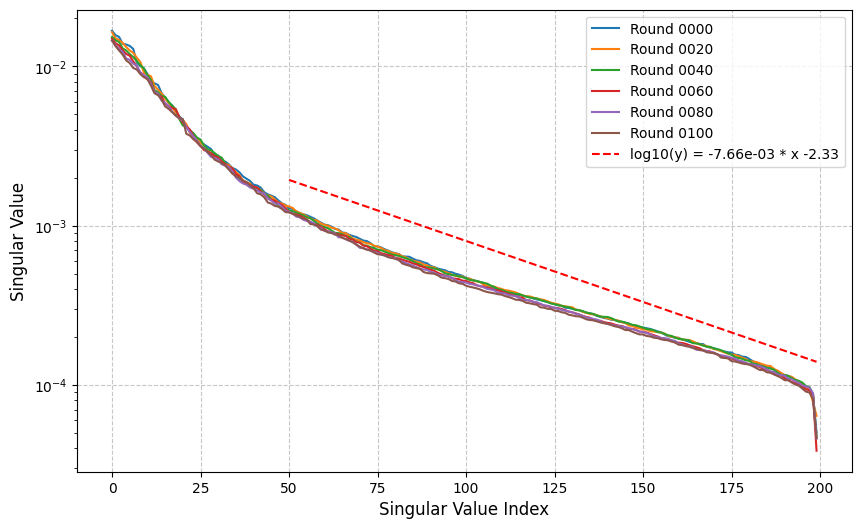

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义要读取的文件轮次列表
steps = ['0000', '0020', '0040', '0060', '0080', '0100']

# 2. 创建画布
plt.figure(figsize=(10, 6))
#plt.xscale('log')
plt.yscale('log')

# 初始化变量以存储 Round 0100 的数据
round_0100_singular_values = None

# 3. 遍历读取文件并绘图
for step in steps:
    filename = f"round_{step}.json"
    
    # 检查文件是否存在，避免因找不到文件而报错
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 提取 _fc1 层的奇异值（注意键名带有下划线）
        if "probe_W_grad_singular_values" in data and "_fc1" in data["probe_W_grad_singular_values"]:
            singular_values = data["probe_W_grad_singular_values"]["_fc1"]
            
            # 绘制当前文件的曲线
            plt.plot(singular_values, label=f'Round {step}', linewidth=1.5)

            # 如果是 Round 0100，则存储数据用于计算拟合线
            if step == '0100':
                round_0100_singular_values = singular_values
        else:
            print(f"警告: 文件 {filename} 中未找到对应的 _fc1 数据。")
    else:
        print(f"找不到文件: {filename}")

# ==============================================================================
# 新增代码：添加拟合虚线
if round_0100_singular_values is not None:
    # 1. 确定计算点
    idx1, idx2 = 50, 150
    
    # 检查数据长度是否足够
    if len(round_0100_singular_values) > idx2:
        # 2. 提取原始点并向上平移
        # 由于是 logarithmic Y 轴，向上平移意味着乘以一个因子。
        # 增加 30% 即乘以 1.3，可根据需要微调这个系数
        shift_factor = 1.6
        y1_shifted = round_0100_singular_values[idx1] * shift_factor
        y2_shifted = round_0100_singular_values[idx2] * shift_factor
        
        # 3. 计算在对数 Y轴下的斜率 (m) 和截距 (b)
        # 拟合方程：log10(y) = m * x + b
        log_y1 = np.log10(y1_shifted)
        log_y2 = np.log10(y2_shifted)
        
        m = (log_y2 - log_y1) / (idx2 - idx1)
        b = log_y1 - m * idx1
        
        # 4. 生成指定范围内的线段数据 (index=50 到 index=175)
        start_idx = 50
        end_idx = 200
        # 确保 end_idx 不超出实际数据长度
        end_idx = min(end_idx, len(round_0100_singular_values) - 1)
        
        # 创建 x 的范围
        x_range = np.arange(start_idx, end_idx + 1)
        # 根据推导出的方程计算对应的 y 值
        y_fitted = 10**(m * x_range + b)
        
        # 5. 格式化表达式文本
        # 使用科学记数法格式化 m，使用浮点数格式化 b
        expr_text = f"log10(y) = {m:.2e} * x {b:.2f}"
        label_text = expr_text
        
        # 6. 绘制红色虚线
        # 设置 color='red', 加粗一点 linewidth=1.5 以保证醒目
        plt.plot(x_range, y_fitted, linestyle='--', color='red', linewidth=1.5, label=label_text)
    else:
        print("警告: Round 0100 数据长度不足以进行 index 150 的计算。")
else:
    print("警告: 未找到 Round 0100 数据，无法添加拟合线。")
# ==============================================================================


# 4. 设置图表的标题、坐标轴标签等属性
#plt.title("Singular Values of W_gradient_fc1 Layer over Rounds", fontsize=14)
plt.xlabel("Singular Value Index", fontsize=12)
plt.ylabel("Singular Value", fontsize=12)

# 【可选】：由于奇异值通常衰减极快（长尾效应），使用对数坐标往往能看清更多细节。
# 如果您发现图像上的线都挤在底部，可以取消下面这行代码的注释来开启 Y 轴的对数坐标：
# plt.yscale('log')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. 保存或显示图像
# plt.savefig("fc1_singular_values_all.png", dpi=300, bbox_inches='tight') # 取消注释可将图片保存到本地
plt.show()

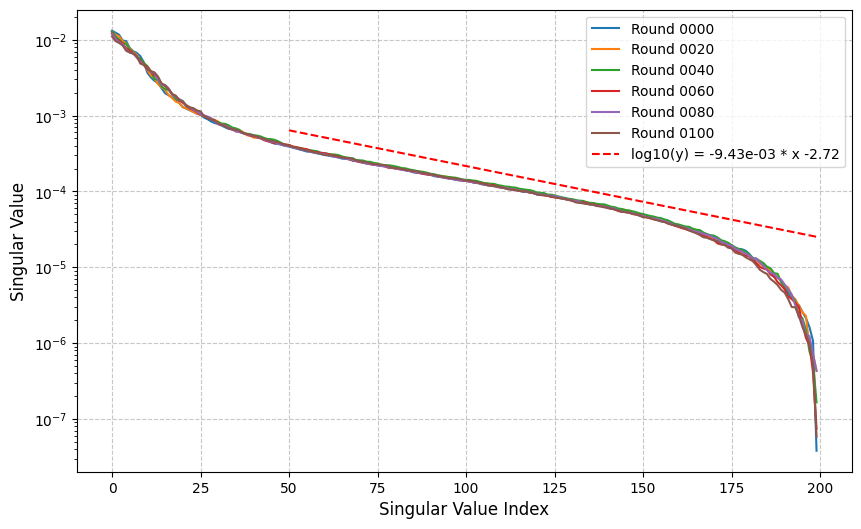

In [2]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np # 导入 numpy 用于对数计算

# 1. 定义要读取的文件轮次列表
steps = ['0000', '0020', '0040', '0060', '0080', '0100']

# 2. 创建画布
plt.figure(figsize=(10, 6))
#plt.xscale('log')
plt.yscale('log')

# 初始化变量以存储 Round 0100 的数据
round_0100_singular_values = None

# 3. 遍历读取文件并绘图
for step in steps:
    filename = f"round_{step}.json"
    
    # 检查文件是否存在，避免因找不到文件而报错
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 提取 _fc2 层的奇异值
        if "probe_W_grad_singular_values" in data and "_fc2" in data["probe_W_grad_singular_values"]:
            singular_values = data["probe_W_grad_singular_values"]["_fc2"]
            
            # 绘制当前文件的曲线
            plt.plot(singular_values, label=f'Round {step}', linewidth=1.5)
            
            # 如果是 Round 0100，则存储数据用于计算拟合线
            if step == '0100':
                round_0100_singular_values = singular_values
        else:
            print(f"警告: 文件 {filename} 中未找到对应的 _fc2 数据。")
    else:
        print(f"找不到文件: {filename}")

# ==============================================================================
# 新增代码：添加拟合虚线
if round_0100_singular_values is not None:
    # 1. 确定计算点
    idx1, idx2 = 50, 150
    
    # 检查数据长度是否足够
    if len(round_0100_singular_values) > idx2:
        # 2. 提取原始点并向上平移
        # 由于是 logarithmic Y 轴，向上平移意味着乘以一个因子。
        # 增加 30% 即乘以 1.3，可根据需要微调这个系数
        shift_factor = 1.6
        y1_shifted = round_0100_singular_values[idx1] * shift_factor
        y2_shifted = round_0100_singular_values[idx2] * shift_factor
        
        # 3. 计算在对数 Y轴下的斜率 (m) 和截距 (b)
        # 拟合方程：log10(y) = m * x + b
        log_y1 = np.log10(y1_shifted)
        log_y2 = np.log10(y2_shifted)
        
        m = (log_y2 - log_y1) / (idx2 - idx1)
        b = log_y1 - m * idx1
        
        # 4. 生成指定范围内的线段数据 (index=50 到 index=175)
        start_idx = 50
        end_idx = 200
        # 确保 end_idx 不超出实际数据长度
        end_idx = min(end_idx, len(round_0100_singular_values) - 1)
        
        # 创建 x 的范围
        x_range = np.arange(start_idx, end_idx + 1)
        # 根据推导出的方程计算对应的 y 值
        y_fitted = 10**(m * x_range + b)
        
        # 5. 格式化表达式文本
        # 使用科学记数法格式化 m，使用浮点数格式化 b
        expr_text = f"log10(y) = {m:.2e} * x {b:.2f}"
        label_text = expr_text
        
        # 6. 绘制红色虚线
        # 设置 color='red', 加粗一点 linewidth=1.5 以保证醒目
        plt.plot(x_range, y_fitted, linestyle='--', color='red', linewidth=1.5, label=label_text)
    else:
        print("警告: Round 0100 数据长度不足以进行 index 150 的计算。")
else:
    print("警告: 未找到 Round 0100 数据，无法添加拟合线。")
# ==============================================================================

# 4. 设置图表的标题、坐标轴标签等属性
#plt.title("Singular Values of W_gradient_fc2 Layer over Rounds", fontsize=14)
plt.xlabel("Singular Value Index", fontsize=12)
plt.ylabel("Singular Value", fontsize=12)

# 【可选】：由于奇异值通常衰减极快（长尾效应），使用对数坐标往往能看清更多细节。
# 如果您发现图像上的线都挤在底部，可以取消下面这行代码的注释来开启 Y 轴的对数坐标：
# plt.yscale('log')

# 确保在所有绘图操作完成后调用 legend()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. 保存或显示图像
# plt.savefig("fc2_singular_values_all.png", dpi=300, bbox_inches='tight') # 取消注释可将图片保存到本地
plt.show()